diabetes9.csv created successfully!

First 5 rows:
   Glucose
0      148
1       85
2      183
3       89
4      137

Dataset shape:
(235, 1)


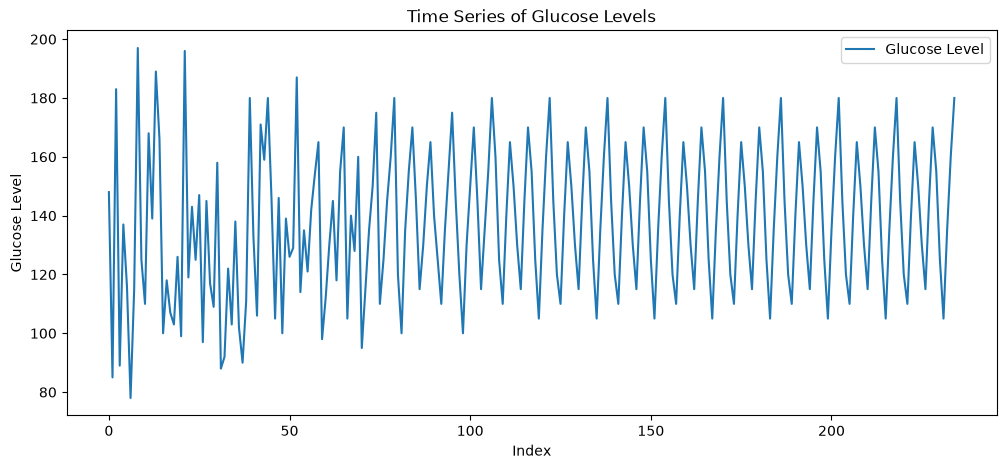

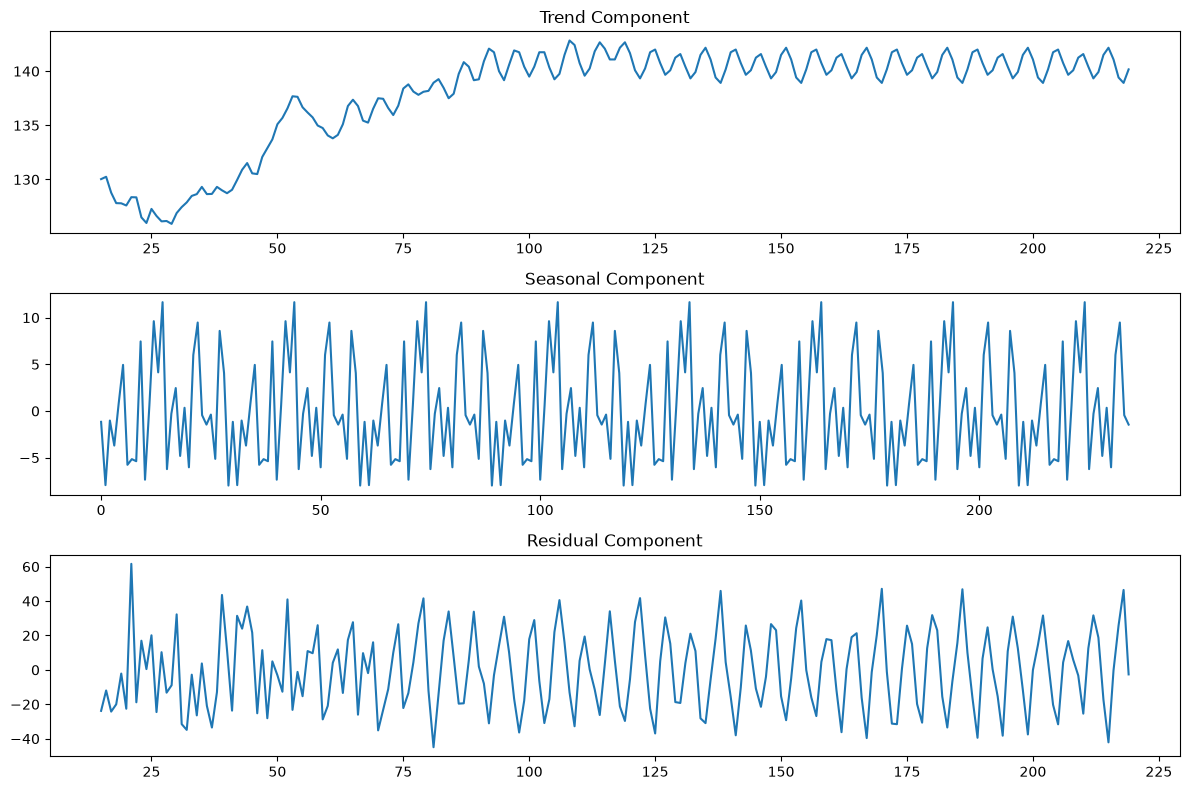

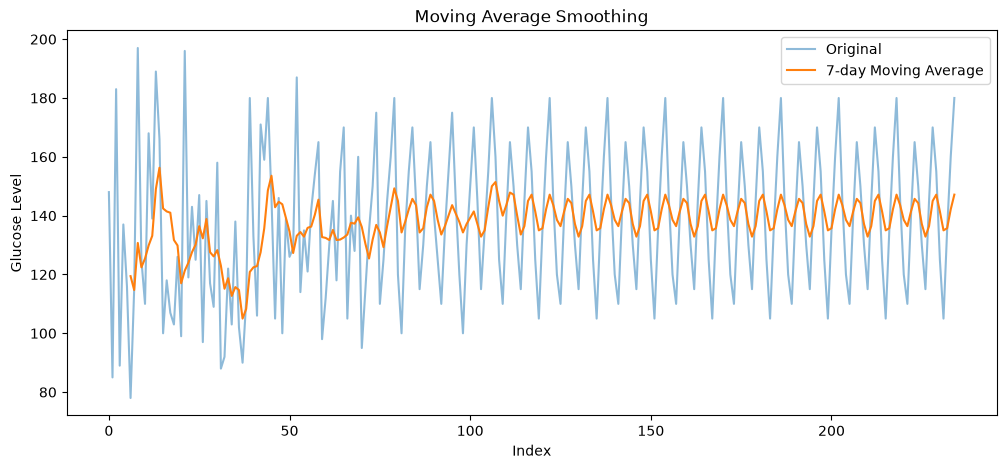


Training data size: 188
Testing data size: 47


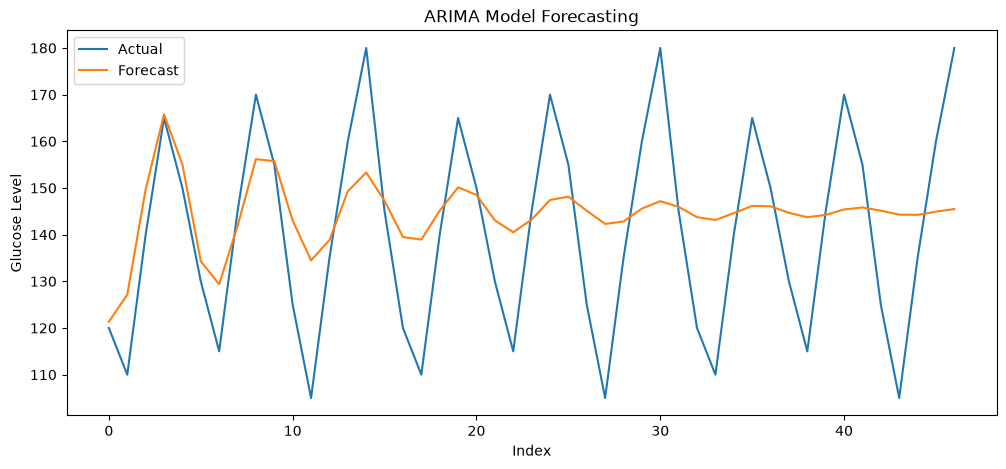


Forecasted Glucose Levels:
188    121.356198
189    127.128114
190    149.695864
191    165.784194
192    155.043694
193    134.309404
194    129.379878
195    141.855154
196    156.181990
197    155.761053
198    143.025067
199    134.493442
200    138.826284
201    149.291940
202    153.322134
203    147.259146
204    139.486586
205    138.954308
206    145.146244
207    150.143891
208    148.509237
209    143.075436
210    140.508190
211    143.243621
212    147.424135
213    148.148077
214    145.122954
215    142.304392
216    142.817489
217    145.586067
218    147.169554
219    145.971798
220    143.753659
221    143.153622
222    144.600150
223    146.164821
224    146.076901
225    144.683675
226    143.742475
227    144.239604
228    145.401641
229    145.826694
230    145.149524
231    144.294686
232    144.246569
233    144.937632
234    145.482425
Name: predicted_mean, dtype: float64


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# ============================================================
# CREATE DATASET DIRECTLY IN THE NOTEBOOK
# ============================================================

data = """
Glucose
148
85
183
89
137
116
78
115
197
125
110
168
139
189
166
100
118
107
103
126
99
196
119
143
125
147
97
145
117
109
158
88
92
122
103
138
102
90
111
180
133
106
171
159
180
146
105
146
100
139
126
129
187
114
135
121
142
154
165
98
112
130
145
118
155
170
105
140
128
160
95
115
135
150
175
110
125
145
160
180
120
100
135
155
170
145
115
130
150
165
140
125
110
135
155
175
145
120
100
130
150
170
145
115
135
155
180
160
125
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
145
120
110
140
165
150
130
115
145
170
155
125
105
135
160
180
"""

# Convert the data into a DataFrame
from io import StringIO

diabetes_data = pd.read_csv(StringIO(data))

# Save it as diabetes9.csv
diabetes_data.to_csv("diabetes9.csv", index=False)

print("diabetes9.csv created successfully!")
print("\nFirst 5 rows:")
print(diabetes_data.head())

print("\nDataset shape:")
print(diabetes_data.shape)


# ============================================================
# PLOT TIME SERIES DATA
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    diabetes_data["Glucose"],
    label="Glucose Level"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.legend()

plt.show()


# ============================================================
# TIME SERIES DECOMPOSITION
# ============================================================

decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=30
)

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 8)
)

decomposition.trend.plot(
    ax=axes[0],
    title="Trend Component"
)

decomposition.seasonal.plot(
    ax=axes[1],
    title="Seasonal Component"
)

decomposition.resid.plot(
    ax=axes[2],
    title="Residual Component"
)

plt.tight_layout()
plt.show()


# ============================================================
# MOVING AVERAGE
# ============================================================

diabetes_data["Glucose_MA"] = (
    diabetes_data["Glucose"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    diabetes_data["Glucose"],
    label="Original",
    alpha=0.5
)

plt.plot(
    diabetes_data["Glucose_MA"],
    label="7-day Moving Average"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Moving Average Smoothing")
plt.legend()

plt.show()


# ============================================================
# ARIMA MODEL
# ============================================================

train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

print("\nTraining data size:", len(train))
print("Testing data size:", len(test))

# ARIMA(p,d,q)
model = ARIMA(
    train,
    order=(5, 1, 0)
)

fitted_model = model.fit()


# ============================================================
# FORECAST
# ============================================================

forecast = fitted_model.forecast(
    steps=len(test)
)


# ============================================================
# PLOT ACTUAL VS FORECAST
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(test)),
    test,
    label="Actual"
)

plt.plot(
    range(len(test)),
    forecast,
    label="Forecast"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("ARIMA Model Forecasting")
plt.legend()

plt.show()


# ============================================================
# DISPLAY FORECAST
# ============================================================

print("\nForecasted Glucose Levels:")
print(forecast)